In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.datasets import make_blobs
from sklearn.cluster import KMeans
from sklearn.cluster import AgglomerativeClustering
from sklearn.datasets import load_iris
from sklearn.cluster import DBSCAN
from sklearn.metrics import silhouette_score
from sklearn.preprocessing import StandardScaler
from scipy.spatial.distance import pdist
from scipy.cluster.hierarchy import linkage, dendrogram

ModuleNotFoundError: No module named 'sklearn'

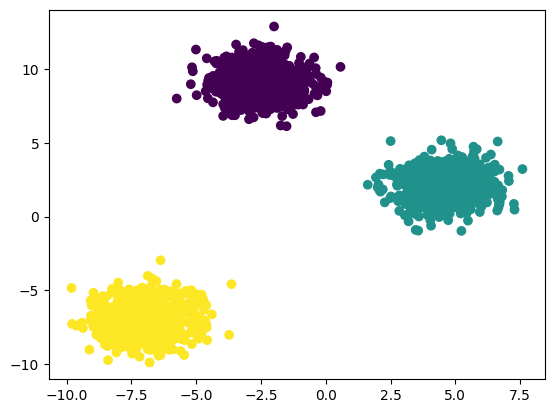

In [ ]:
k = 3
X, y = make_blobs(n_samples=2000, centers=k, random_state=42)
plt.scatter(X[:, 0], X[:, 1], c=y)

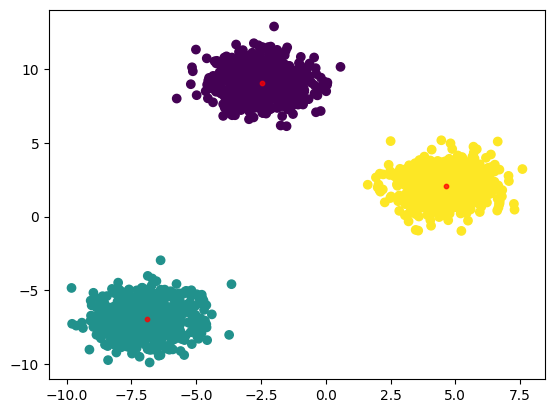

In [ ]:
def euclidean_distance(x, y):
    return np.sqrt(np.sum((x - y)**2))

def create_centroids(data, k):
    centers = [data[np.random.randint(0, data.shape[0])]]

    for _ in range(k - 1):
        d_list = []
        for row in data:
            min_d = float('inf')
            for c in centers:
                d = euclidean_distance(row, c)
                if d < min_d:
                    min_d = d
            d_list.append(min_d)
        
        d_arr = np.array(d_list)
        next_center = data[np.argmax(d_arr)]
        centers.append(next_center)
    
    return np.array(centers)

def new_clusters(data, centers):
    cluster_ids = []
    for row in data:
        all_dists = [euclidean_distance(row, c) for c in centers]
        cluster_ids.append(np.argmin(all_dists))
    return np.array(cluster_ids)

def new_centroids(data, cluster_ids, k):
    return np.array([data[cluster_ids == idx].mean(axis=0) for idx in range(k)])

centers = create_centroids(X, k)

for i in range(500):
    cluster_ids = new_clusters(X, centers)
    new_centers = new_centroids(X, cluster_ids, k)
    
    if np.allclose(centers, new_centers):
        break
    centers = new_centers

plt.scatter(X[:, 0], X[:, 1], c=cluster_ids)
plt.scatter(centers[:, 0], centers[:, 1], color='red', s=10, alpha=0.75)
plt.show()


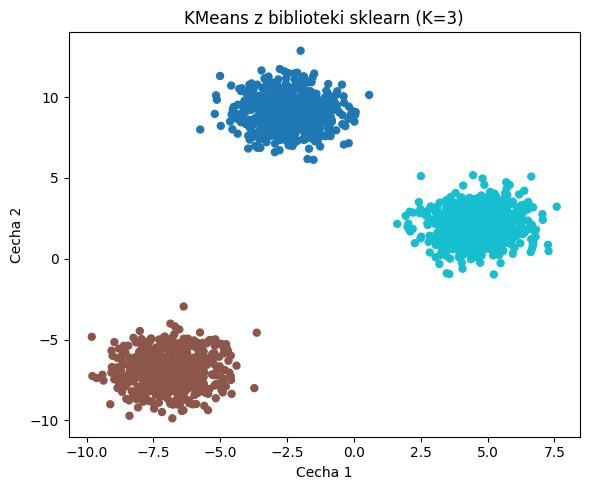

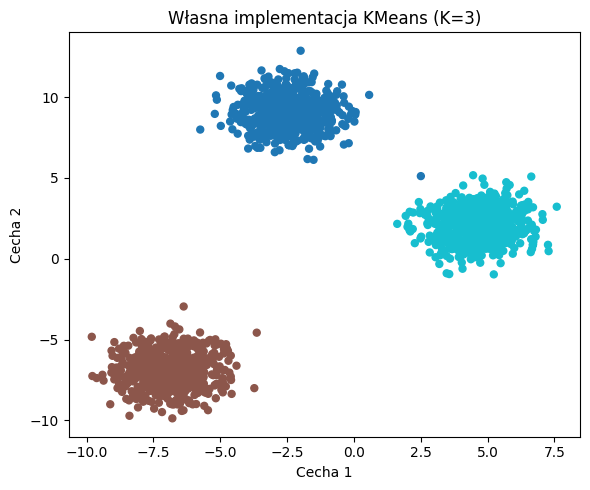

In [ ]:
model = KMeans(n_clusters=k, random_state=42, n_init=100)
labels_sklearn = model.fit_predict(X)

plt.figure(figsize=(6, 5))
plt.scatter(X[:, 0], X[:, 1], c=labels_sklearn, s=25, cmap="tab10")
plt.title("KMeans z biblioteki sklearn (K=3)")
plt.xlabel("Cecha 1")
plt.ylabel("Cecha 2")
plt.tight_layout()
plt.show()

centroids = create_centroids(X, k)
labels_custom = new_clusters(X, centroids)

plt.figure(figsize=(6, 5))
plt.scatter(X[:, 0], X[:, 1], c=labels_custom, s=25, cmap="tab10")
plt.title("Własna implementacja KMeans (K=3)")
plt.xlabel("Cecha 1")
plt.ylabel("Cecha 2")
plt.tight_layout()
plt.show()

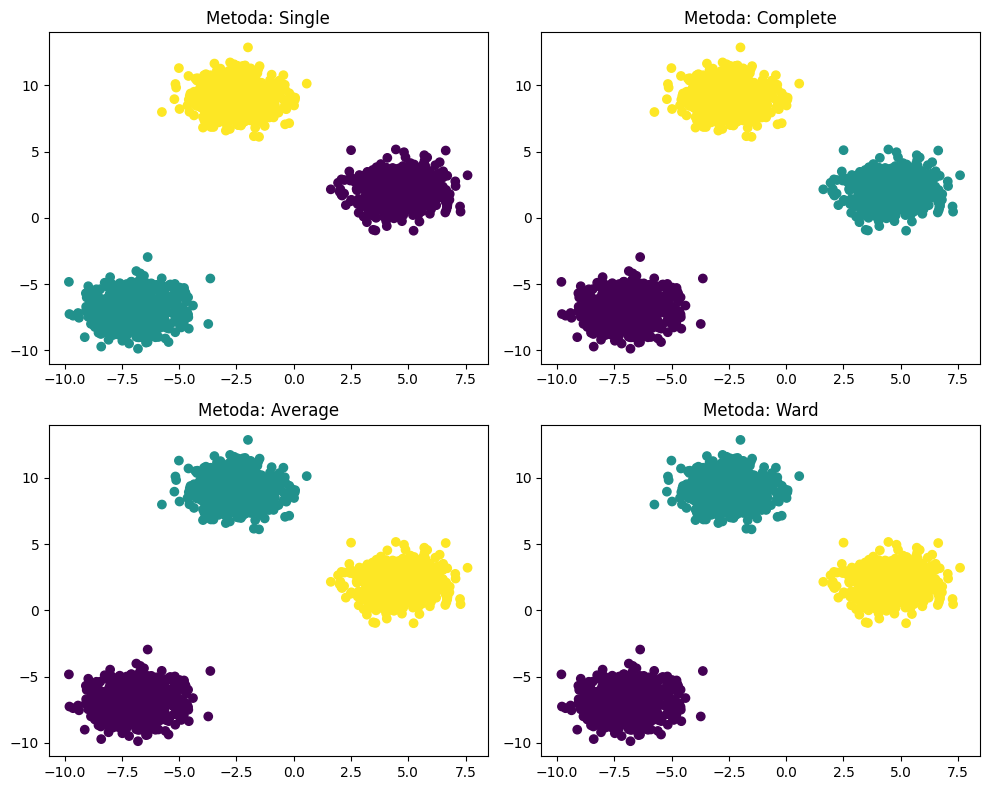

In [ ]:
link_methods = ['single', 'complete', 'average', 'ward']
fig, axs = plt.subplots(nrows=2, ncols=2, figsize=(10, 8))

for idx, link_type in enumerate(link_methods):
    row, col = divmod(idx, 2)
    ax = axs[row, col]

    model = AgglomerativeClustering(n_clusters=3, linkage=link_type)
    model.fit(X)

    ax.scatter(X[:, 0], X[:, 1], c=model.labels_)
    ax.set_title(f'Metoda: {link_type.title()}')

plt.tight_layout()
plt.show()

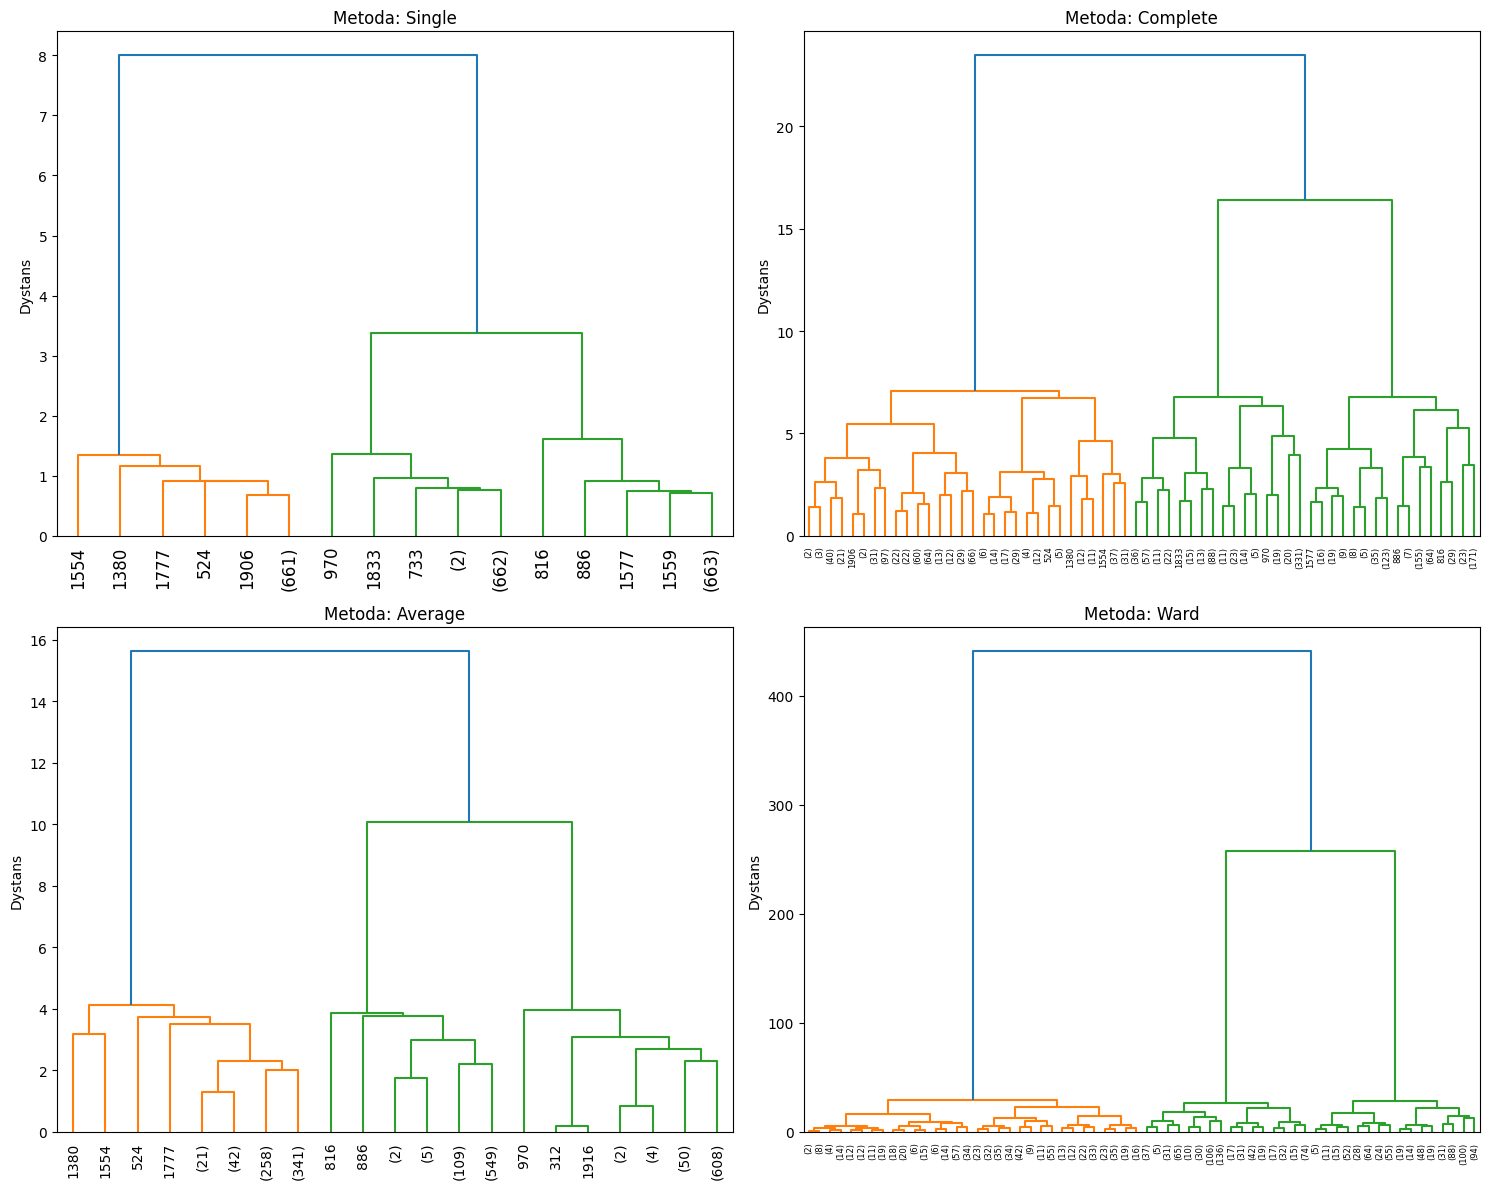

In [ ]:

link_methods = ['single', 'complete', 'average', 'ward']
fig, axs = plt.subplots(nrows=2, ncols=2, figsize=(15, 12))

for idx, link_type in enumerate(link_methods):
    row, col = divmod(idx, 2)
    ax = axs[row, col]

    if link_type == 'ward':
        linkage_matrix = linkage(X, method=link_type)
    else:
        linkage_matrix = linkage(X, method=link_type, metric='euclidean')
    
    dendrogram(linkage_matrix, ax=ax, truncate_mode='level', p=5)
    ax.set_title(f'Metoda: {link_type.title()}')
    ax.set_ylabel('Dystans')

    for tick in ax.get_xticklabels():
        tick.set_rotation(90)

plt.tight_layout()
plt.show()


In [ ]:
iris = load_iris()
iris_data = iris.data

def elbow_method(X, max_k=10):
    sse = []
    k_range = range(1, max_k + 1)
    
    for k in k_range:
        if k == 1:
            sse.append(np.sum((X - X.mean(axis=0))**2))
        else:
            kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)
            kmeans.fit(X)
            sse.append(kmeans.inertia_)
    
    return k_range, sse

def silhouette_analysis(X, max_k=10):
    silhouette_scores = []
    k_range = range(2, max_k + 1)  
    
    for k in k_range:
        kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)
        labels = kmeans.fit_predict(X)
        score = silhouette_score(X, labels)
        silhouette_scores.append(score)
    
    return k_range, silhouette_scores

In [ ]:
k_range, sse = elbow_method(iris_data, max_k=10)
k_range_sil, silhouette_scores = silhouette_analysis(iris_data, max_k=10)

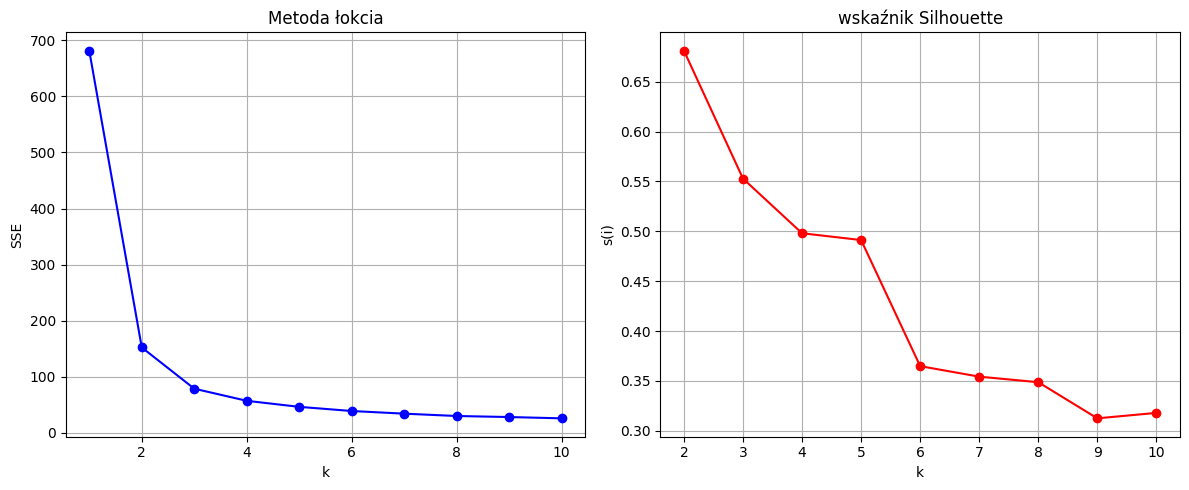

In [ ]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 5))

ax1.plot(k_range, sse, 'bo-')
ax1.set_xlabel('k')
ax1.set_ylabel('SSE')
ax1.set_title('Metoda łokcia')
ax1.grid(True)

ax2.plot(k_range_sil, silhouette_scores, 'ro-')
ax2.set_xlabel('k')
ax2.set_ylabel('s(i)')
ax2.set_title('wskaźnik Silhouette')
ax2.grid(True)

plt.tight_layout()
plt.show()

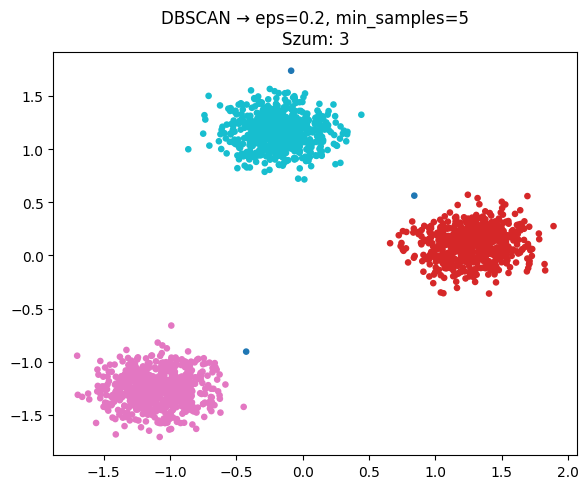

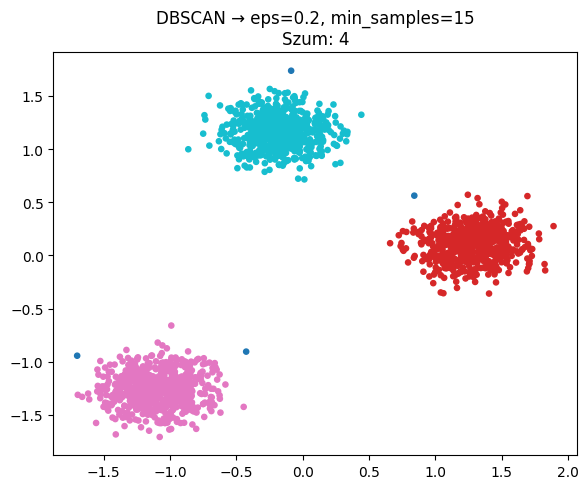

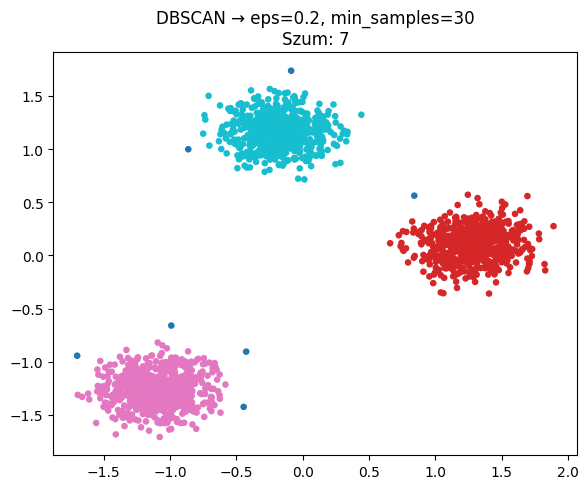

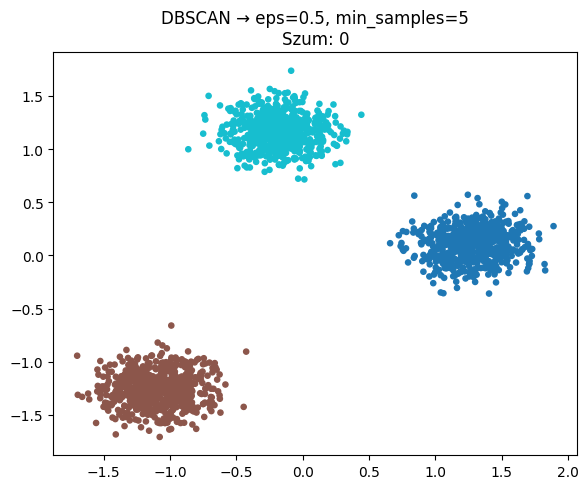

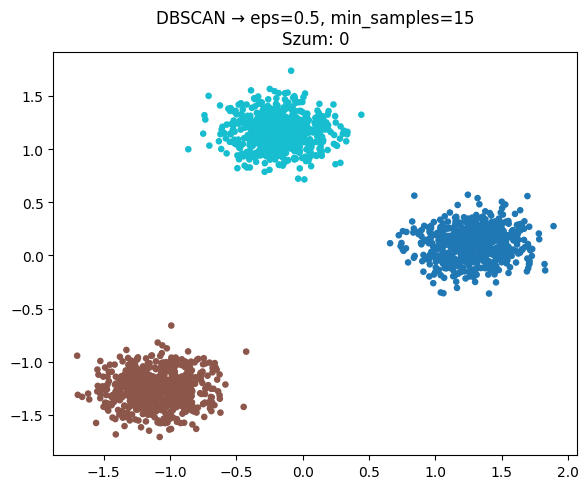

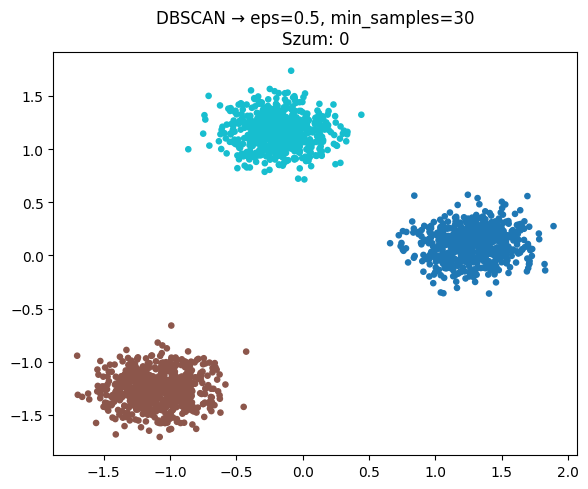

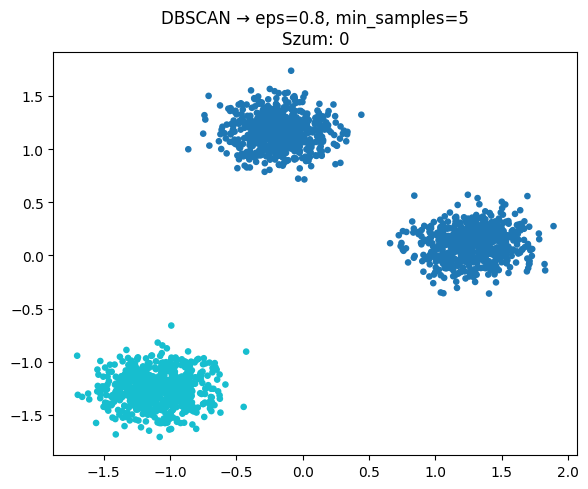

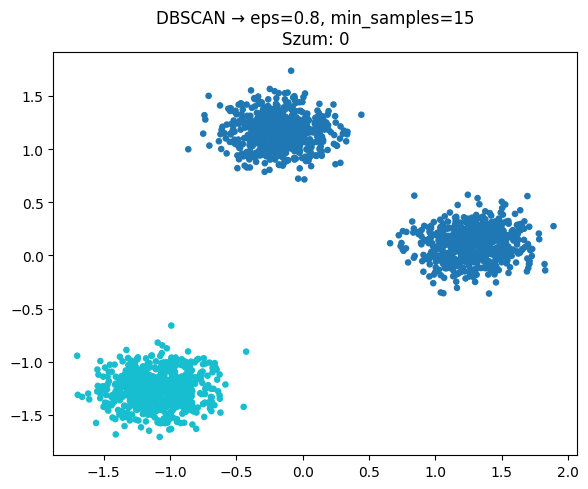

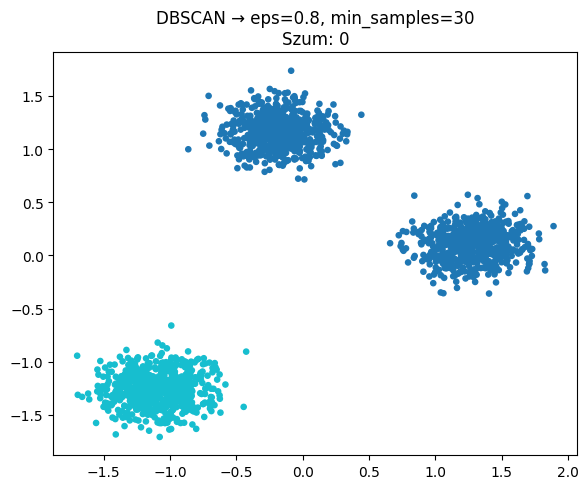

In [ ]:
scaler = StandardScaler()
X_std = scaler.fit_transform(X)
n_clusters = 3

def test_dbscan(eps_values, min_samples_values):
    for eps_val in eps_values:
        for min_s in min_samples_values:
            model = DBSCAN(eps=eps_val, min_samples=min_s)
            model.fit(X_std)
            
            labels = model.labels_
            n_noise = np.sum(labels == -1)
            
            plt.figure(figsize=(6, 5))
            plt.scatter(X_std[:, 0], X_std[:, 1], c=labels, s=14, cmap="tab10")
            plt.title(
                f"DBSCAN → eps={eps_val}, min_samples={min_s}\n"
                f"Szum: {n_noise}"
            )
            plt.tight_layout()
            plt.show()

test_dbscan(
    eps_values=[0.2, 0.5, 0.8],
    min_samples_values=[5, 15, 30]
)

In [ ]:
data = pd.read_csv("../data/Mall_Customers.csv")

NameError: name 'pd' is not defined

In [ ]:
kneedle = KneeLocator(k_range, sse, curve="convex", direction="decreasing")
elbow_k = kneedle.elbow

In [ ]:
X_mall = data[["Age", "Annual Income (k$)"]].values
X_scaled = StandardScaler().fit_transform(X_mall)
kmeans_model = KMeans(n_clusters=5, random_state=42, n_init=10)
labels = kmeans_model.fit_predict(X_scaled)


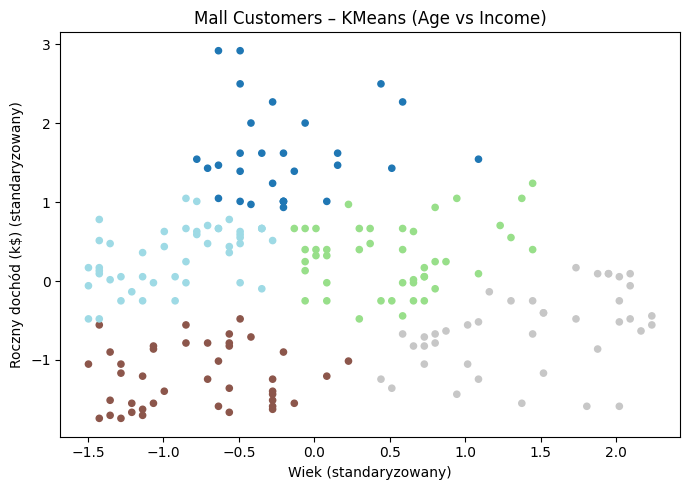

In [ ]:
plt.figure(figsize=(7, 5))
plt.scatter(X_scaled[:, 0], X_scaled[:, 1], c=labels, s=20, cmap="tab20")
plt.title("Mall Customers – KMeans (Age vs Income)")
plt.xlabel("Wiek (standaryzowany)")
plt.ylabel("Roczny dochód (k$) (standaryzowany)")
plt.tight_layout()
plt.show()